# 03 — Method 2: Sentence-BERT Semantic Retrieval
## UniMatch: Arabic Student Advising Chatbot

### Dataset Setup
| Role | File | Size |
|------|------|------|
| Index (knowledge base) | `faq_enhanced.csv` | 280 questions |
| Test queries | 4 paraphrases per question | 1,120 queries |

### Evaluation Protocol
- **Index:** built on `question` column only (no leakage)
- **Query:** paraphrases (`question_alt`, `alt2`, `alt3`, `alt4`)
- **Ground truth:** `answer` column must match exactly

## Cell 1 — Install

In [1]:
!pip install -q sentence-transformers scikit-learn pandas matplotlib

## Cell 2 — Mount Drive & Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR   = '/content/drive/MyDrive/Student_chatbot/'
DATA_DIR   = os.path.join(BASE_DIR, 'data/')
MODEL_DIR  = os.path.join(BASE_DIR, 'models/')
RESULT_DIR = os.path.join(BASE_DIR, 'results/')

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print('Checking required files:')
for f in ['faq_enhanced.csv']:
    path = os.path.join(DATA_DIR, f)
    print(f'  {f:25s} {"✅" if os.path.exists(path) else "❌ MISSING"}')

Mounted at /content/drive
Checking required files:
  faq_enhanced.csv          ✅


## Cell 3 — Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print('Imports done ✅')

Imports done ✅


## Cell 4 — Load Dataset

In [4]:
# Index = ALL questions (full knowledge base)
df_index = pd.read_csv(os.path.join(DATA_DIR, 'faq_enhanced.csv'))

# Build test queries — 4 paraphrases per question
long_rows = []
for _, row in df_index.iterrows():
    for col in ['question_alt', 'question_alt2',
                'question_alt3', 'question_alt4']:
        if col in row and pd.notna(row[col]):
            long_rows.append({
                'question': row['question'],
                'answer'  : row['answer'],
                'query'   : row[col],
            })

df_test = pd.DataFrame(long_rows)

print(f'Index (full)  : {len(df_index)} questions ✅')
print(f'Test queries  : {len(df_test)} queries ✅')
print(f'  ({len(df_index)} questions × 4 paraphrases)')
display(df_index.head(3))
display(df_test.head(4))

Index (full)  : 280 questions ✅
Test queries  : 1120 queries ✅
  (280 questions × 4 paraphrases)


,question,answer,question_alt,question_alt2,question_alt3,question_alt4
0,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟,ما تاريخ تأسيس كلية الاقتصاد والأعمال؟,منذ متى تأسست كلية الاقتصاد والأعمال؟
1,ما الهدف من إنشاء كلية الاقتصاد والأعمال؟,تهدف كلية الاقتصاد والأعمال إلى إعداد وتأهيل خ...,ما الغرض الذي أُسست من أجله كلية الاقتصاد والأ...,ما الغاية من إنشاء كلية الاقتصاد والأعمال؟,ما غرض إنشاء كلية الاقتصاد والأعمال؟,لماذا يُقدَّم إنشاء كلية الاقتصاد والأعمال؟
2,كم عدد الأقسام في كلية الاقتصاد والأعمال؟,تضم كلية الاقتصاد والأعمال خمسة أقسام.,كم قسمًا تحتوي كلية الاقتصاد والأعمال؟,ما عدد الأقسام في كلية الاقتصاد والأعمال؟,كم يبلغ عدد الأقسام في كلية الاقتصاد والأعمال؟,كم الأقسام في كلية الاقتصاد والأعمال يوجد؟


,question,answer,query
0,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟
1,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟
2,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,ما تاريخ تأسيس كلية الاقتصاد والأعمال؟
3,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,منذ متى تأسست كلية الاقتصاد والأعمال؟


## Cell 5 — Load Sentence-BERT Model

In [5]:
MODEL_NAME = 'paraphrase-multilingual-MiniLM-L12-v2'

print(f'Loading model: {MODEL_NAME}')
model = SentenceTransformer(MODEL_NAME)

print(f'Model loaded ✅')
print(f'Embedding dimension : {model.get_sentence_embedding_dimension()}')
print(f'Max sequence length : {model.max_seq_length}')

Loading model: paraphrase-multilingual-MiniLM-L12-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded ✅
Embedding dimension : 384
Max sequence length : 128


## Cell 6 — Build BERT Embeddings Index
⚠️ Index built on `question` only — no paraphrases in index.

In [6]:
emb_path = os.path.join(MODEL_DIR, 'bert_embeddings_v2.npy')

if os.path.exists(emb_path):
    print('Loading cached embeddings...')
    bert_embeddings = np.load(emb_path)
    print(f'Loaded: {bert_embeddings.shape} ✅')
else:
    print('Computing embeddings for all questions...')
    bert_embeddings = model.encode(
        df_index['question'].tolist(),
        batch_size           = 32,
        show_progress_bar    = True,
        normalize_embeddings = True
    )
    np.save(emb_path, bert_embeddings)
    print(f'Saved: {bert_embeddings.shape} ✅')

print(f'\nEmbedding shape : {bert_embeddings.shape}')
print(f'  Rows = FAQ pairs   : {bert_embeddings.shape[0]}')
print(f'  Cols = dimensions  : {bert_embeddings.shape[1]}')

Computing embeddings for all questions...


Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Saved: (280, 384) ✅

Embedding shape : (280, 384)
  Rows = FAQ pairs   : 280
  Cols = dimensions  : 384


## Cell 7 — Retrieval Function

In [7]:
def retrieve_bert(query, model, embeddings, df_index, top_k=5):
    """
    Retrieve top-k answers using Sentence-BERT cosine similarity.
    Searches against df_index (full knowledge base).
    """
    q_emb   = model.encode([query], normalize_embeddings=True)
    scores  = cosine_similarity(q_emb, embeddings)[0]
    top_idx = np.argsort(scores)[::-1][:top_k]

    top_k_results = [
        (df_index.iloc[i]['question'], float(scores[i]))
        for i in top_idx
    ]

    best_idx = top_idx[0]
    return (
        df_index.iloc[best_idx]['answer'],
        float(scores[best_idx]),
        df_index.iloc[best_idx]['question'],
        top_k_results
    )

print('Retrieval function defined ✅')

Retrieval function defined ✅


## Cell 8 — Test on Sample Queries

In [8]:
sample_queries = df_test['query'].sample(4, random_state=42).tolist()

print('Sentence-BERT Retrieval — Sample Results')
print('='*65)
for q in sample_queries:
    answer, score, matched, _ = retrieve_bert(
        q, model, bert_embeddings, df_index)
    print(f'\n  Query   : {q}')
    print(f'  Matched : {matched}')
    print(f'  Score   : {score:.4f}')
    print(f'  Answer  : {answer[:80]}...')
print('\n' + '='*65)

Sentence-BERT Retrieval — Sample Results

  Query   : ما معنى تأجيل الدراسة؟
  Matched : ما المقصود بتأجيل الدراسة؟
  Score   : 0.9482
  Answer  : تأجيل الدراسة هو إيقاف الطالب لدراسته بشكل مؤقّت لفترة محددة وفق أنظمة الجامعة، ...

  Query   : ما الهدف من دراسة تخصص المحاسبة والتدقيق المالي؟
  Matched : ما الغاية من دراسة تخصص المحاسبة والتدقيق المالي؟
  Score   : 0.9879
  Answer  : يهدف تخصص المحاسبة والتدقيق المالي إلى تزويد الخريجين بالمعرفة والكفاءات اللازمة...

  Query   : ما معنى الخدمات الإلكترونية في الجامعة بشكل عام؟
  Matched : ما هي الخدمات الإلكترونية في الجامعة؟
  Score   : 0.9345
  Answer  : هي مجموعة من الأنظمة والمواقع التي توفرها الجامعة للطلاب عبر الإنترنت، لتسهيل إن...

  Query   : هل يمكنك الإجابة عن: ما هي خطوات التسجيل للطالب الجديد؟
  Matched : ما هي خطوات التسجيل للطالب الجديد؟
  Score   : 0.9458
  Answer  : تبدأ الخطوات بتقديم طلب الالتحاق، ثم قبول الطالب، بعدها دفع الرسوم، وأخيرًا تسجي...



## Cell 9 — Evaluation Function

In [9]:
def evaluate_bert(df_test, model, embeddings, df_index):
    """
    Evaluate Sentence-BERT on test queries.

    df_test  : test queries — columns: [question, answer, query]
    model    : SentenceTransformer
    embeddings: pre-computed embeddings of df_index questions
    df_index : full knowledge base
    """
    correct_at1, correct_at3 = [], []
    rr_list, time_list       = [], []
    all_scores               = []

    for _, row in df_test.iterrows():
        query       = row['query']       # paraphrase query
        true_answer = row['answer']      # ground truth

        t_start = time.time()
        q_emb   = model.encode([query], normalize_embeddings=True)
        scores  = cosine_similarity(q_emb, embeddings)[0]
        elapsed = (time.time() - t_start) * 1000

        top5_idx = np.argsort(scores)[::-1][:5]
        top5_ans = [df_index.iloc[i]['answer'] for i in top5_idx]

        # Accuracy@1
        correct_at1.append(top5_ans[0].strip() == true_answer.strip())

        # Accuracy@3
        correct_at3.append(
            true_answer.strip() in [a.strip() for a in top5_ans[:3]])

        # MRR
        rr = 0
        for rank, ans in enumerate(top5_ans, 1):
            if ans.strip() == true_answer.strip():
                rr = 1 / rank
                break
        rr_list.append(rr)
        time_list.append(elapsed)
        all_scores.append(float(scores[top5_idx[0]]))

    return {
        'Accuracy@1'   : np.mean(correct_at1) * 100,
        'Accuracy@3'   : np.mean(correct_at3) * 100,
        'MRR'          : np.mean(rr_list),
        'Avg Score'    : np.mean(all_scores),
        'Avg Time (ms)': np.mean(time_list),
        'details'      : {
            'correct_at1': correct_at1,
            'scores'     : all_scores,
            'times'      : time_list,
        }
    }

print('Evaluation function defined ✅')

Evaluation function defined ✅


## Cell 10 — Run Evaluation

In [10]:
print('Running Sentence-BERT evaluation...')
print(f'  Index size : {len(df_index)} questions')
print(f'  Test size  : {len(df_test)} queries (4 paraphrases × {len(df_index)} questions)')

metrics = evaluate_bert(df_test, model, bert_embeddings, df_index)

print('\n' + '='*50)
print('  SENTENCE-BERT EVALUATION RESULTS')
print('='*50)
print(f'  Accuracy@1    : {metrics["Accuracy@1"]:.2f}%')
print(f'  Accuracy@3    : {metrics["Accuracy@3"]:.2f}%')
print(f'  MRR           : {metrics["MRR"]:.4f}')
print(f'  Avg Score     : {metrics["Avg Score"]:.4f}')
print(f'  Avg Time (ms) : {metrics["Avg Time (ms)"]:.2f}')
print(f'  Index size    : {len(df_index)}')
print(f'  Test queries  : {len(df_test)}')
print('='*50)

Running Sentence-BERT evaluation...
  Index size : 280 questions
  Test size  : 1120 queries (4 paraphrases × 280 questions)

  SENTENCE-BERT EVALUATION RESULTS
  Accuracy@1    : 92.59%
  Accuracy@3    : 97.95%
  MRR           : 0.9528
  Avg Score     : 0.9312
  Avg Time (ms) : 45.88
  Index size    : 280
  Test queries  : 1120


## Cell 11 — Score Distribution Plot

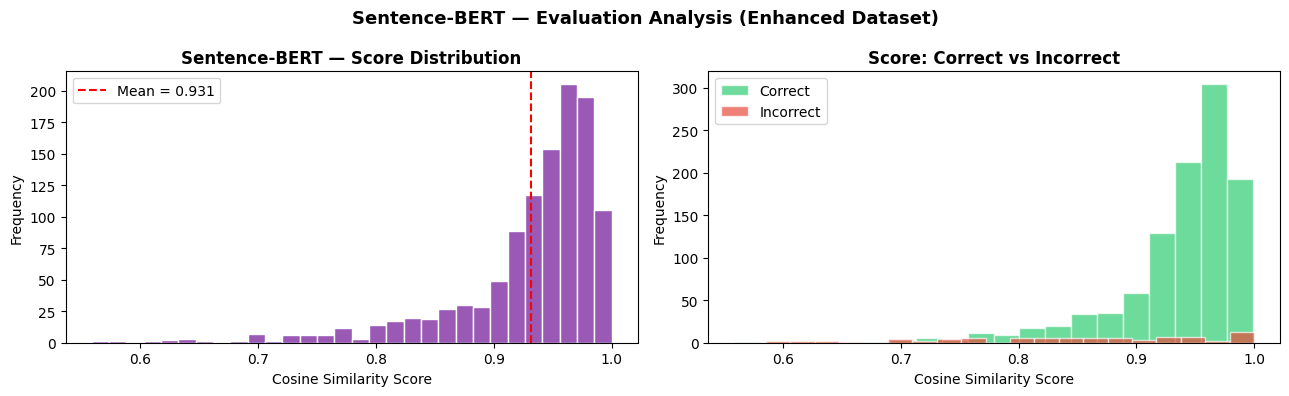

Plot saved ✅


In [11]:
scores_list      = metrics['details']['scores']
correct_list     = metrics['details']['correct_at1']
correct_scores   = [s for s, c in zip(scores_list, correct_list) if c]
incorrect_scores = [s for s, c in zip(scores_list, correct_list) if not c]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(scores_list, bins=30, color='#9b59b6', edgecolor='white')
axes[0].axvline(np.mean(scores_list), color='red', linestyle='--',
                label=f'Mean = {np.mean(scores_list):.3f}')
axes[0].set_title('Sentence-BERT — Score Distribution', fontweight='bold')
axes[0].set_xlabel('Cosine Similarity Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(correct_scores,   bins=20, alpha=0.7,
             color='#2ecc71', edgecolor='white', label='Correct')
axes[1].hist(incorrect_scores, bins=20, alpha=0.7,
             color='#e74c3c', edgecolor='white', label='Incorrect')
axes[1].set_title('Score: Correct vs Incorrect', fontweight='bold')
axes[1].set_xlabel('Cosine Similarity Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Sentence-BERT — Evaluation Analysis (Enhanced Dataset)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join(RESULT_DIR, 'bert_score_distribution_v2.png'), dpi=150)
plt.show()
print('Plot saved ✅')

## Cell 12 — Compare with TF-IDF

TF-IDF vs Sentence-BERT (Enhanced Dataset):


,Metric,TF-IDF,BERT,Delta
0,Accuracy@1,90.0900,92.5893,2.4993
1,Accuracy@3,98.0400,97.9464,-0.0936
2,MRR,0.9399,0.9528,0.0129
3,Avg Score,0.8008,0.9312,0.1304
4,Avg Time (ms),1.5900,45.8847,44.2947


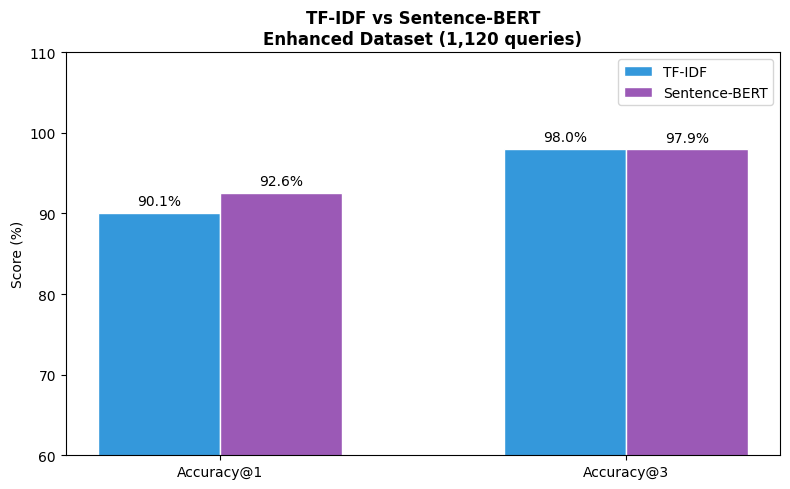

Comparison plot saved ✅


In [12]:
# TF-IDF results from notebook 02b
tfidf_results = {
    'Accuracy@1'   : 90.09,
    'Accuracy@3'   : 98.04,
    'MRR'          : 0.9399,
    'Avg Score'    : 0.8008,
    'Avg Time (ms)': 1.59,
}

bert_results = {
    'Accuracy@1'   : metrics['Accuracy@1'],
    'Accuracy@3'   : metrics['Accuracy@3'],
    'MRR'          : metrics['MRR'],
    'Avg Score'    : metrics['Avg Score'],
    'Avg Time (ms)': metrics['Avg Time (ms)'],
}

compare_df = pd.DataFrame({
    'Metric' : list(tfidf_results.keys()),
    'TF-IDF' : list(tfidf_results.values()),
    'BERT'   : [round(v, 4) for v in bert_results.values()],
})
compare_df['Delta'] = (compare_df['BERT'] - compare_df['TF-IDF']).round(4)

print('TF-IDF vs Sentence-BERT (Enhanced Dataset):')
display(compare_df)

# Bar chart
metrics_plot = ['Accuracy@1', 'Accuracy@3']
x = np.arange(len(metrics_plot))
w = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2,
            [tfidf_results[m] for m in metrics_plot],
            w, label='TF-IDF', color='#3498db', edgecolor='white')
b2 = ax.bar(x + w/2,
            [bert_results[m] for m in metrics_plot],
            w, label='Sentence-BERT', color='#9b59b6', edgecolor='white')
ax.bar_label(b1, fmt='%.1f%%', padding=3)
ax.bar_label(b2, fmt='%.1f%%', padding=3)
ax.set_xticks(x)
ax.set_xticklabels(metrics_plot)
ax.set_ylabel('Score (%)')
ax.set_ylim(60, 110)
ax.set_title('TF-IDF vs Sentence-BERT\nEnhanced Dataset (1,120 queries)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(RESULT_DIR, 'tfidf_vs_bert_v2.png'), dpi=150)
plt.show()
print('Comparison plot saved ✅')

## Cell 13 — Save Results

In [13]:
# Save embeddings
np.save(emb_path, bert_embeddings)

# Save metrics
metrics_df = pd.DataFrame([{
    'Method'       : 'Sentence-BERT',
    'Accuracy@1'   : round(metrics['Accuracy@1'], 2),
    'Accuracy@3'   : round(metrics['Accuracy@3'], 2),
    'MRR'          : round(metrics['MRR'], 4),
    'Avg Score'    : round(metrics['Avg Score'], 4),
    'Avg Time (ms)': round(metrics['Avg Time (ms)'], 2),
    'Index Size'   : len(df_index),
    'Test Queries' : len(df_test),
}])
metrics_df.to_csv(
    os.path.join(RESULT_DIR, 'bert_results_v2.csv'), index=False)

print('='*50)
print('  SAVED FILES')
print('='*50)
print(f'  models/bert_embeddings_v2.npy')
print(f'  results/bert_results_v2.csv')
print(f'  results/bert_score_distribution_v2.png')
print(f'  results/tfidf_vs_bert_v2.png')
print('='*50)
display(metrics_df)
print(f'\nNext → 04_method3_BM25_BERT_Hybrid.ipynb')

  SAVED FILES
  models/bert_embeddings_v2.npy
  results/bert_results_v2.csv
  results/bert_score_distribution_v2.png
  results/tfidf_vs_bert_v2.png


,Method,Accuracy@1,Accuracy@3,MRR,Avg Score,Avg Time (ms),Index Size,Test Queries
0,Sentence-BERT,92.59,97.95,0.9528,0.9312,45.88,280,1120



Next → 04_method3_BM25_BERT_Hybrid.ipynb
